# Frozen DINOv2-large — Embedding Analysis
**9-stage pipeline.** Each stage answers one question, has explicit pass/fail criteria,
and saves its artefacts to `outputs/analysis/stage<N>/`.

Run `10_qc_embeddings.ipynb` first (produces the embeddings this notebook loads).

| Stage | Question | Pass |
|---|---|---|
| 1 | Is there structure at all? | PCA non-flat, UMAP organised |
| 2 | Do clusters exist? | Silhouette > 0.10, stable ARI |
| 3 | Does the label separation hold up? | sep_ratio > 1, p < 0.05, confounds balanced |
| 4 | Intra/inter class distances | sep_ratio > 1, permutation p < 0.05 |
| 5 | Multi-image consistency | N/A — 1 fig/patent |
| 6 | What is encoded? | Probe AUC > 0.7 |
| 7 | Confound testing | Design signal not explained by confounds |
| 8 | Layer comparison | Best layer identified |
| 9 | Temporal / genealogical signal | Year not decodable |


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config_loader import load_config
from src import data, embeddings, analysis

cfg  = load_config()
SEED = cfg['analysis']['seed']

result          = embeddings.load_embeddings(cfg)
arrays, metadata = result['arrays'], result['metadata']
yb              = analysis.binary_labels(metadata)   # 1=shrouded, 0=open

BASE = Path(cfg['paths']['output_dir'])
OUT  = {i: BASE / f'stage{i}' for i in range(1, 10)}
for p in OUT.values():
    p.mkdir(parents=True, exist_ok=True)

print('matrices :', sorted(arrays.keys()))
print(f'figures  : {len(yb)}  shrouded={int(yb.sum())}  open={int((1-yb).sum())}')


matrices : [(18, 'cls'), (18, 'mean_patch'), (22, 'cls'), (22, 'mean_patch'), (24, 'cls'), (24, 'mean_patch')]
figures  : 72  shrouded=32  open=40


## Stage 0 — QC Report (loaded from stage0/)
Embeddings were validated in `10_qc_embeddings.ipynb`. Table below is loaded from the saved CSV — no recomputation.

**Pass criteria:** 0 NaN, 0 Inf, 0 all-zero rows across all 6 matrices.

In [2]:
_qc_path = BASE / 'stage0' / 'qc_embedding_report.csv'
if not _qc_path.exists():
    _qc_path = BASE / 'qc_embedding_report.csv'   # fallback: old location
_qc = pd.read_csv(_qc_path)

_fmt = {c: '{:.4f}' for c in ['cos_mean','cos_std','cos_p05','cos_p50','cos_p95',
                               'dim_var_mean','dim_var_min','dim_var_max']}
def _hl(s):
    best = s == s.max(); worst = s == s.min()
    return ['background-color:#c6efce' if b else 'background-color:#ffc7ce' if w else ''
            for b,w in zip(best,worst)]
(_qc.style
    .format(_fmt)
    .apply(_hl, subset=['cos_mean'])
    .set_caption('Stage-0 QC Report  (green = best cos_mean, red = worst)')
    .set_table_styles([
        {'selector':'caption','props':[('font-size','13px'),('font-weight','bold')]},
        {'selector':'th','props':[('background-color','#4472c4'),('color','white'),('text-align','center')]},
        {'selector':'td','props':[('text-align','center'),('padding','4px 10px')]},
    ])
)


,layer,pooling,variant,n_layers,hidden_dim,num_register_tokens,n_prefix,emb_dim,n_figures,n_patents,fig_per_patent_min,fig_per_patent_median,fig_per_patent_max,nan_count,inf_count,all_zero_count,exact_duplicate_count,dim_var_mean,dim_var_min,dim_var_max,near_dead_dims,cos_mean,cos_std,cos_p05,cos_p50,cos_p95
0,18,cls,base,24,1024,0,1,1024,72,72,1,1.000000,1,0,0,0,0,0.0000,0.0000,0.0006,0,0.9591,0.0177,0.9253,0.9630,0.9804
1,18,mean_patch,base,24,1024,0,1,1024,72,72,1,1.000000,1,0,0,0,0,0.0001,0.0000,0.0020,0,0.8554,0.0515,0.7597,0.8626,0.9266
2,22,cls,base,24,1024,0,1,1024,72,72,1,1.000000,1,0,0,0,0,0.0001,0.0000,0.0021,0,0.8806,0.0401,0.7940,0.8888,0.9262
3,22,mean_patch,base,24,1024,0,1,1024,72,72,1,1.000000,1,0,0,0,0,0.0001,0.0000,0.0015,0,0.8629,0.0435,0.7855,0.8682,0.9222
4,24,cls,base,24,1024,0,1,1024,72,72,1,1.000000,1,0,0,0,0,0.0005,0.0000,0.0046,0,0.4536,0.1035,0.2826,0.4539,0.6191
5,24,mean_patch,base,24,1024,0,1,1024,72,72,1,1.000000,1,0,0,0,0,0.0002,0.0000,0.0022,0,0.8241,0.0522,0.7290,0.8296,0.8977


## Stage 1 — Global Structure
**Question:** do the embeddings contain any structure at all?  
**Input:** raw embedding matrices (all 6 layer × pooling combinations).  
**Outputs:** `pca_stats.csv`, `pca_umap_plot.png`, `stage1_verdict.png`.  
**Pass:** PCA spectrum non-flat (PC1 real/random ≥ 3×); UMAP shows organisation.  
**Fail:** structure indistinguishable from random Gaussian baseline.


I0000 00:00:1782818332.122466  280871 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


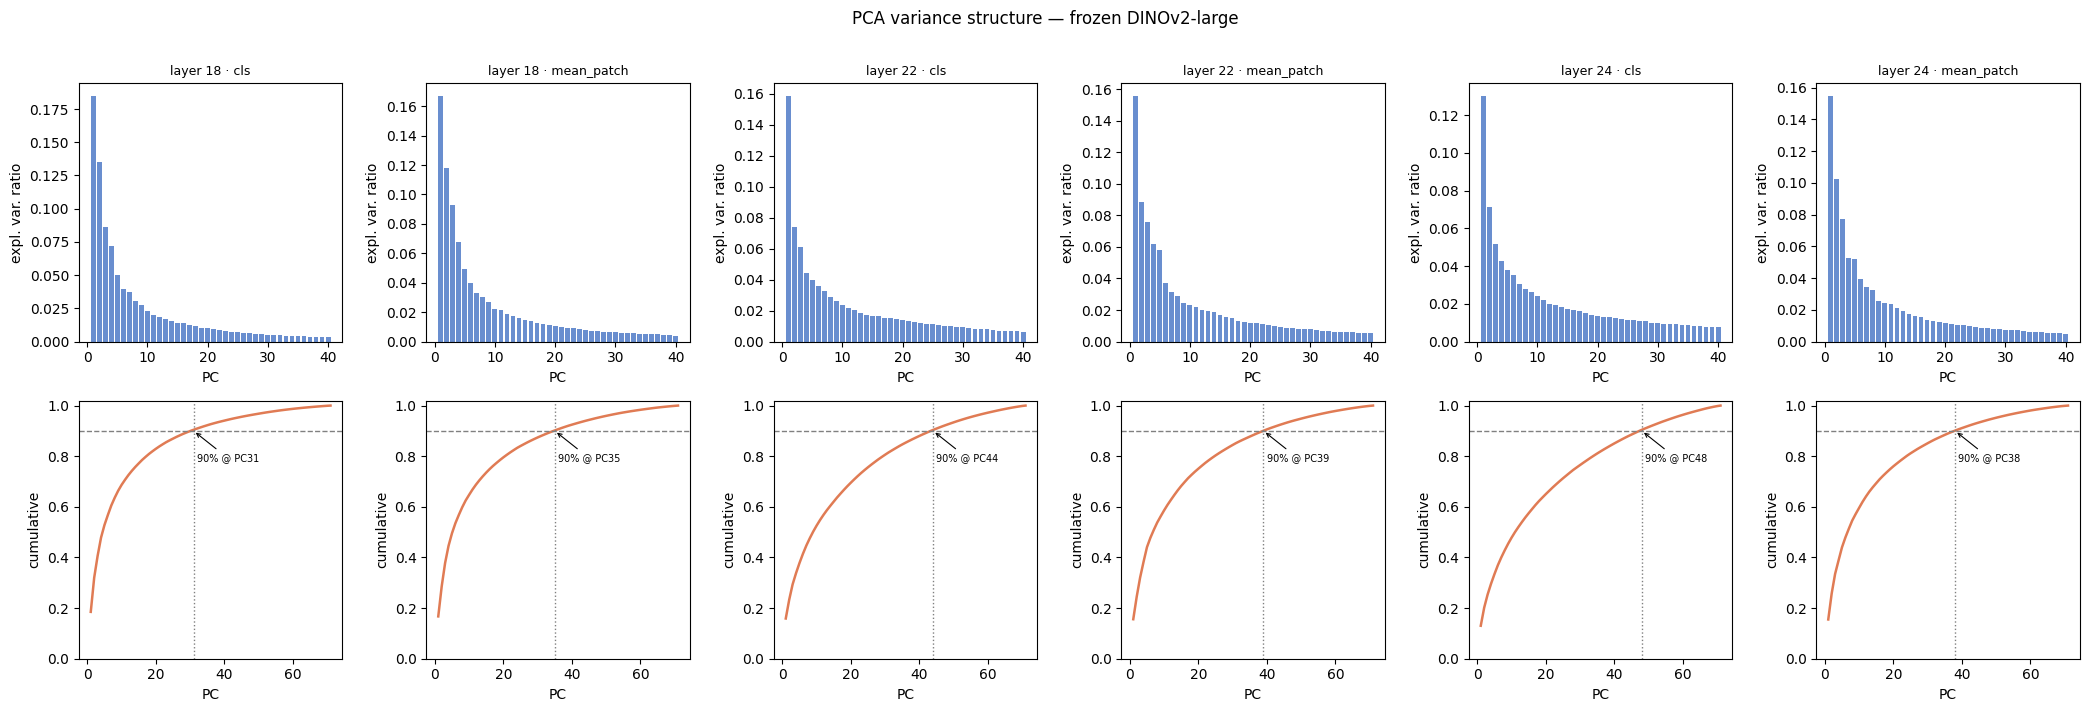

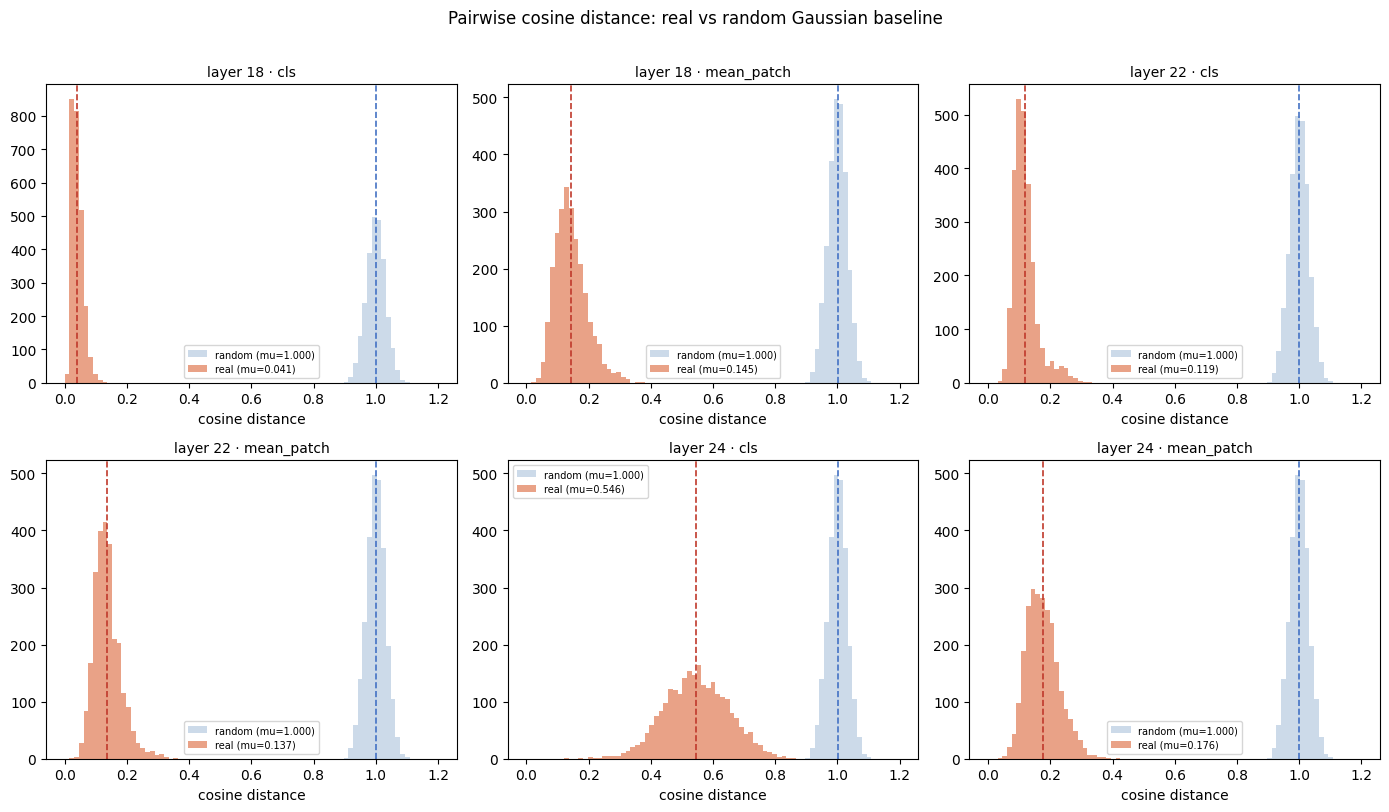

/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


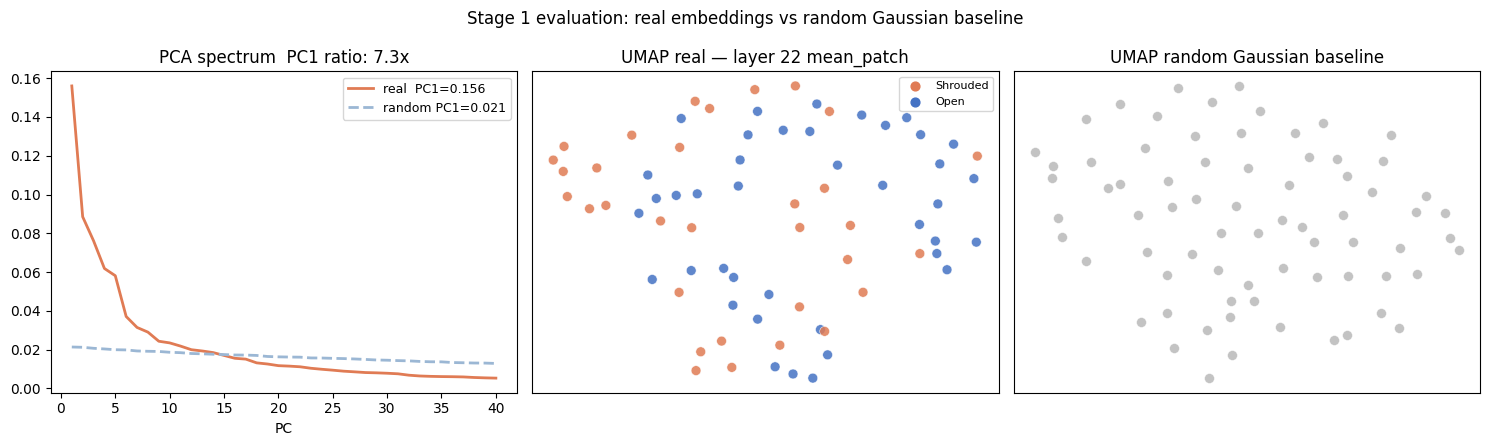

  PCA non-flat (PC1 ratio >= 3x) : PASS  (7.3x)
  UMAP organisation               : inspect plot above
  STAGE 1: PASS


In [3]:
from sklearn.decomposition import PCA as _PCA
from src.analysis import _l2, _pairwise
import umap as _umap

# ── 1a: PCA variance structure (all 6 matrices) ──────────────────────────────
keys = sorted(arrays.keys())
fig, axes = plt.subplots(2, len(keys), figsize=(3.5 * len(keys), 7))
pca_rows = []
for col, (L, pool) in enumerate(keys):
    X  = _l2(arrays[(L, pool)])
    pca = _PCA(n_components=min(71, X.shape[1])).fit(X)
    ev, cum = pca.explained_variance_ratio_, np.cumsum(pca.explained_variance_ratio_)
    pcs = np.arange(1, len(ev) + 1)
    axes[0, col].bar(pcs[:40], ev[:40], color='#4472c4', alpha=0.8)
    axes[0, col].set_title(f'layer {L} · {pool}', fontsize=9)
    axes[0, col].set_xlabel('PC'); axes[0, col].set_ylabel('expl. var. ratio')
    axes[1, col].plot(pcs, cum, color='#e07b54', lw=1.8)
    axes[1, col].axhline(0.90, color='gray', ls='--', lw=1)
    n90 = int(np.searchsorted(cum, 0.90)) + 1
    axes[1, col].axvline(n90, color='gray', ls=':', lw=1)
    axes[1, col].annotate(f'90% @ PC{n90}', xy=(n90, 0.90), xytext=(n90+1, 0.78),
                          fontsize=7, arrowprops=dict(arrowstyle='->', lw=0.8))
    axes[1, col].set_xlabel('PC'); axes[1, col].set_ylabel('cumulative'); axes[1, col].set_ylim(0, 1.02)
    for i, (e, c) in enumerate(zip(ev, cum)):
        pca_rows.append({'layer': L, 'pooling': pool, 'pc': i+1,
                         'expl_var_ratio': round(float(e), 6),
                         'cumulative_var_ratio': round(float(c), 6)})
fig.suptitle('PCA variance structure — frozen DINOv2-large', y=1.01)
fig.tight_layout()
fig.savefig(OUT[1] / 'pca_umap_plot.png', dpi=130, bbox_inches='tight')
plt.show()
pd.DataFrame(pca_rows).to_csv(OUT[1] / 'pca_stats.csv', index=False)


# ── 1c: Pairwise cosine distance — real vs random (all 6 matrices) ───────────
from src.analysis import _l2, _pairwise as _pw
_rng = np.random.default_rng(SEED)
_n, _d = next(iter(arrays.values())).shape
_X_rand_all = _l2(_rng.standard_normal((_n, _d)).astype(np.float32))
_rand_dist, _, _, _ = _pw(_X_rand_all, np.zeros(_n, dtype=int))
_rand_mean = _rand_dist.mean()
_keys = sorted(arrays.keys())
_fig, _axes = plt.subplots(2, 3, figsize=(14, 8))
for _ax, (L, pool) in zip(_axes.ravel(), _keys):
    _Xr = _l2(arrays[(L, pool)])
    _rd, _, _, _ = _pw(_Xr, np.zeros(_n, dtype=int))
    _bins = np.linspace(0, 1.2, 80)
    _ax.hist(_rand_dist, bins=_bins, alpha=0.5, color='#9bb7d4', label=f'random (mu={_rand_mean:.3f})')
    _ax.hist(_rd,        bins=_bins, alpha=0.7, color='#e07b54', label=f'real (mu={_rd.mean():.3f})')
    _ax.axvline(_rand_mean,   color='#4472c4', lw=1.2, ls='--')
    _ax.axvline(_rd.mean(),   color='#c0392b', lw=1.2, ls='--')
    _ax.set_title(f'layer {L} · {pool}', fontsize=10)
    _ax.set_xlabel('cosine distance'); _ax.legend(fontsize=7)
_fig.suptitle('Pairwise cosine distance: real vs random Gaussian baseline', y=1.01)
_fig.tight_layout()
_fig.savefig(OUT[1] / 'random_baseline_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

# ── 1b + 1d: Random baseline comparison + Stage 1 verdict ────────────────────
EVAL = (22, 'mean_patch')
X_real  = _l2(arrays[EVAL])
X_rand  = _l2(np.random.default_rng(SEED).standard_normal(X_real.shape).astype(np.float32))
n_pcs   = min(len(X_real) - 1, 40)
ev_real = _PCA(n_components=n_pcs, random_state=SEED).fit(X_real).explained_variance_ratio_
ev_rand = _PCA(n_components=n_pcs, random_state=SEED).fit(X_rand).explained_variance_ratio_
pca_ratio = float(ev_real[0] / ev_rand[0])

umap_kw = dict(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=SEED)
emb_real = _umap.UMAP(**umap_kw).fit_transform(X_real)
emb_rand = _umap.UMAP(**umap_kw).fit_transform(X_rand)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(np.arange(1, n_pcs+1), ev_real, color='#e07b54', lw=2, label=f'real  PC1={ev_real[0]:.3f}')
axes[0].plot(np.arange(1, n_pcs+1), ev_rand, color='#9bb7d4', lw=2, ls='--', label=f'random PC1={ev_rand[0]:.3f}')
axes[0].set_title(f'PCA spectrum  PC1 ratio: {pca_ratio:.1f}x'); axes[0].set_xlabel('PC'); axes[0].legend(fontsize=9)
COLORS_e = np.where(yb == 1, '#e07b54', '#4472c4')
axes[1].scatter(emb_real[:, 0], emb_real[:, 1], c=COLORS_e, s=50, alpha=0.85, edgecolors='white', lw=0.4)
axes[1].set_title(f'UMAP real — layer {EVAL[0]} {EVAL[1]}'); axes[1].set_xticks([]); axes[1].set_yticks([])
for c, lbl in [('#e07b54','Shrouded'), ('#4472c4','Open')]: axes[1].scatter([], [], c=c, label=lbl, s=40)
axes[1].legend(fontsize=8)
axes[2].scatter(emb_rand[:, 0], emb_rand[:, 1], c='#aaaaaa', s=50, alpha=0.7, edgecolors='white', lw=0.4)
axes[2].set_title('UMAP random Gaussian baseline'); axes[2].set_xticks([]); axes[2].set_yticks([])
fig.suptitle('Stage 1 evaluation: real embeddings vs random Gaussian baseline', fontsize=12)
fig.tight_layout()
fig.savefig(OUT[1] / 'stage1_verdict.png', dpi=130, bbox_inches='tight')
plt.show()

pca_pass = pca_ratio >= 3.0
print('=' * 50)
print(f'  PCA non-flat (PC1 ratio >= 3x) : {"PASS" if pca_pass else "FAIL"}  ({pca_ratio:.1f}x)')
print(f'  UMAP organisation               : inspect plot above')
print('  STAGE 1:', 'PASS' if pca_pass else 'FAIL')
print('=' * 50)


## Stage 2 — Unsupervised Clustering
**Question:** do coherent groups emerge without using the shrouded/open label?  
**Input:** PCA-reduced embeddings (pcs_90 dims from Stage 1).  
**Outputs:** `dendrogram.png`, `umap_clusters.png`, `cluster_labels.csv`, `cluster_metrics.csv`, `cluster_stability.png`.  
**Pass:** Silhouette > 0.10, bootstrap ARI > 0.60, no extreme fragmentation.  
**Fail:** all noise, one dominant cluster, or unstable partitions.


Input: layer 22 mean_patch  PCA dim=39


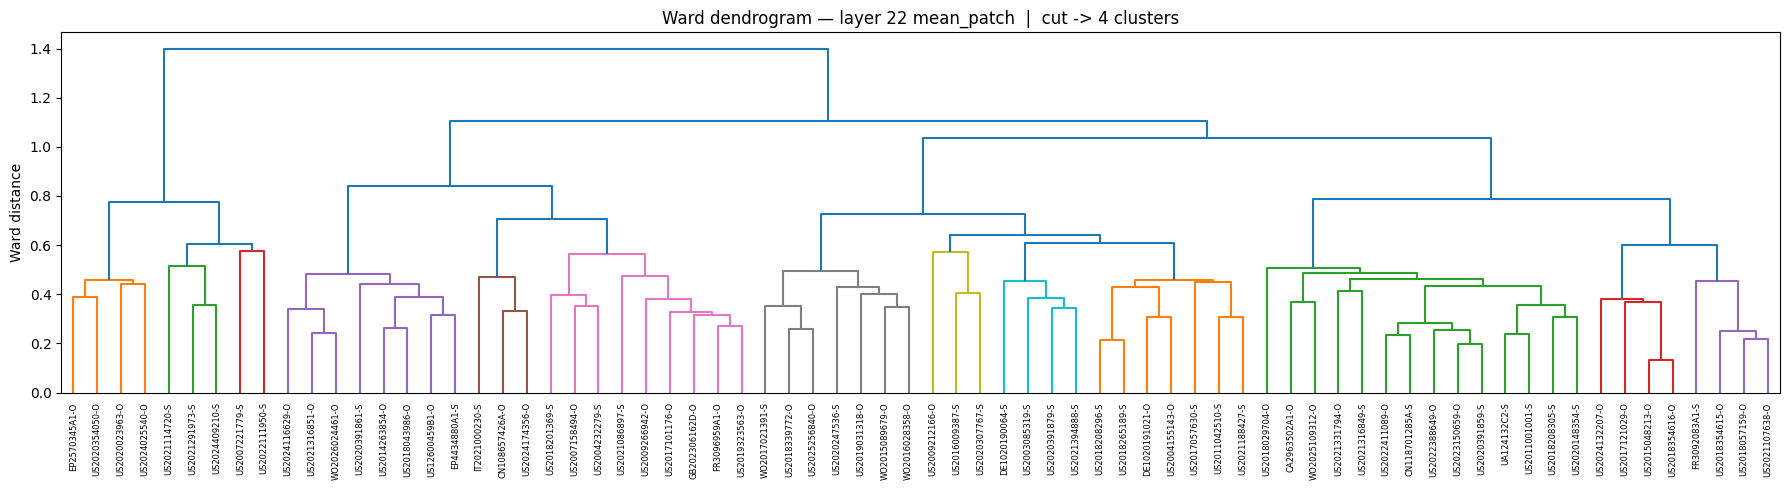

Hierarchical: 4 clusters  dominant fraction=0.31
[list_figures] scanned: /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1627_DS/Shrouded vs Openrotor/Images Processed
[list_figures] found 72 figures across 72 distinct patent_ids

[list_figures] CONFIRM the parse convention (showing first 12):
                                   figure_id        patent_id shrouded_open        cpc figure_type
     CA2963502A1_OPN_B64C290025_p001_c01.png      CA2963502A1           OPN B64C290025    p001_c01
    CN108657426A_OPN_B64C290033_p007_c04.png     CN108657426A           OPN B64C290033    p007_c04
DE102019102189A1_OPN_B64C290033_p014_c07.png DE102019102189A1           OPN B64C290033    p014_c07
     EP2570345A1_OPN_B64C290033_p009_c05.png      EP2570345A1           OPN B64C290033    p009_c05
       FR3096959A1_OPN_B64U5014_p012_c03.png      FR3096959A1           OPN   B64U5014    p012_c03
   GB202306162D0_OPN_B64C290033_p001_c01.png    GB202306162D0           OPN

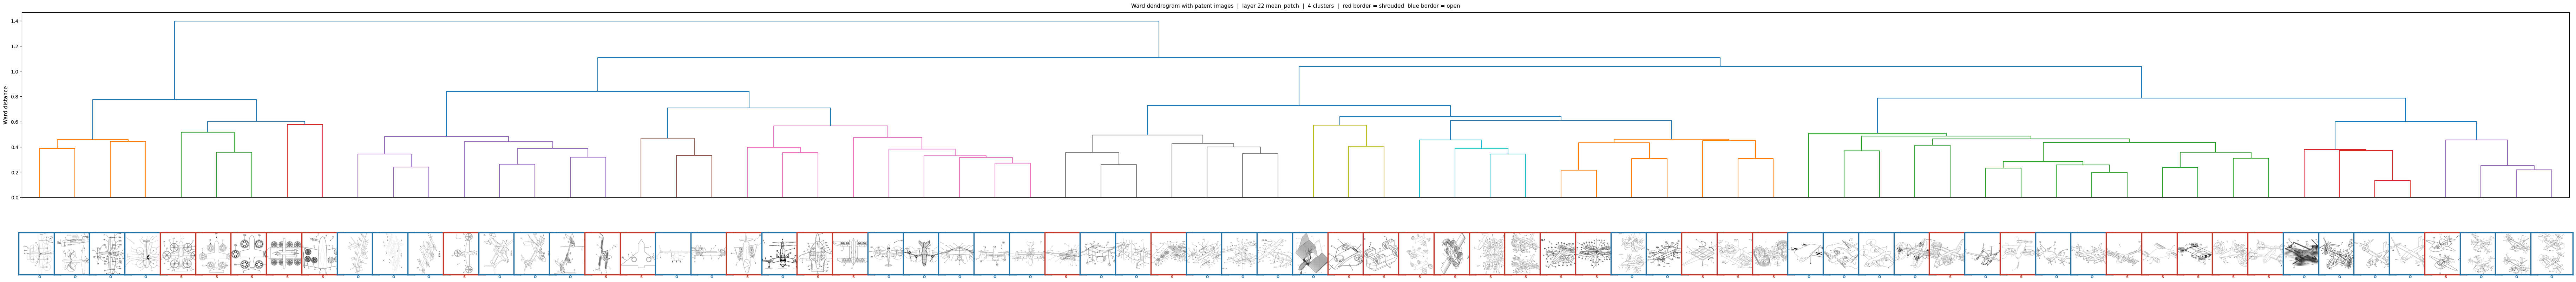

HDBSCAN: 0 clusters  noise=72 (100%)


,method,k,silhouette,davies_bouldin,calinski_harabasz
0,kmeans,2,0.180,2.139,9.5
1,hierarchical,2,0.207,1.909,8.8
2,kmeans,3,0.083,2.586,8.4
3,hierarchical,3,0.085,2.554,7.6
4,kmeans,4,0.096,2.279,7.6
5,hierarchical,4,0.084,2.411,7.3


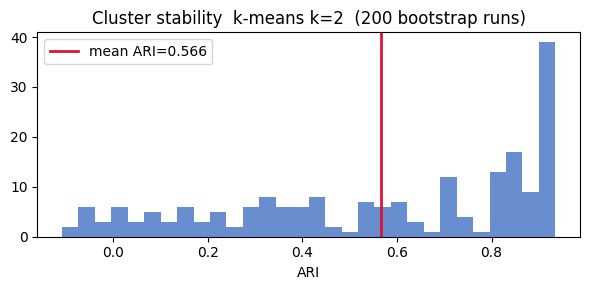

/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


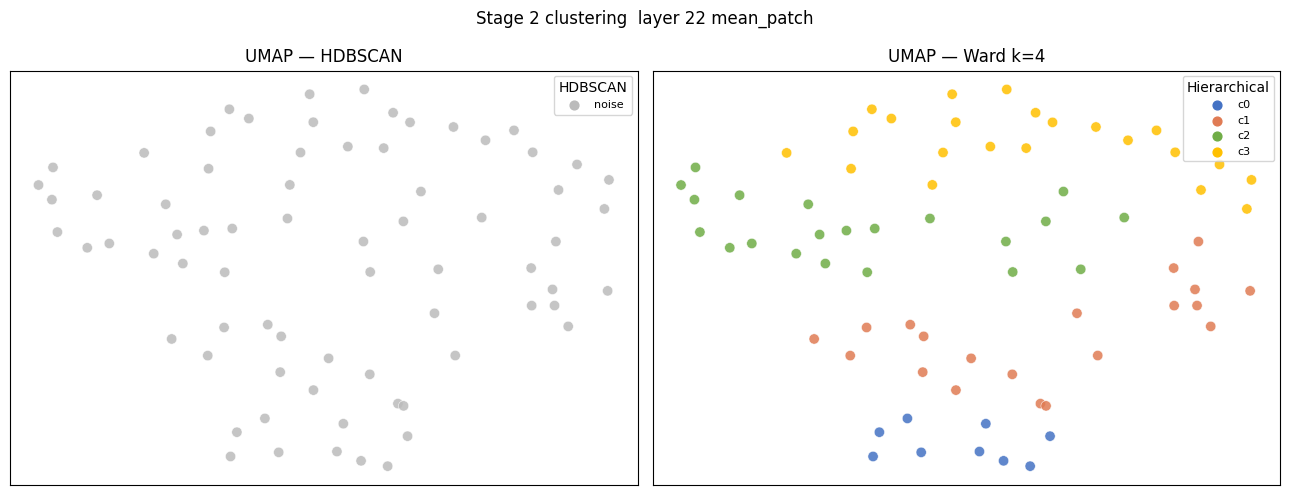

[list_figures] scanned: /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1627_DS/Shrouded vs Openrotor/Images Processed
[list_figures] found 72 figures across 72 distinct patent_ids

[list_figures] CONFIRM the parse convention (showing first 12):
                                   figure_id        patent_id shrouded_open        cpc figure_type
     CA2963502A1_OPN_B64C290025_p001_c01.png      CA2963502A1           OPN B64C290025    p001_c01
    CN108657426A_OPN_B64C290033_p007_c04.png     CN108657426A           OPN B64C290033    p007_c04
DE102019102189A1_OPN_B64C290033_p014_c07.png DE102019102189A1           OPN B64C290033    p014_c07
     EP2570345A1_OPN_B64C290033_p009_c05.png      EP2570345A1           OPN B64C290033    p009_c05
       FR3096959A1_OPN_B64U5014_p012_c03.png      FR3096959A1           OPN   B64U5014    p012_c03
   GB202306162D0_OPN_B64C290033_p001_c01.png    GB202306162D0           OPN B64C290033    p001_c01
    US12600459B1_OPN_B64C

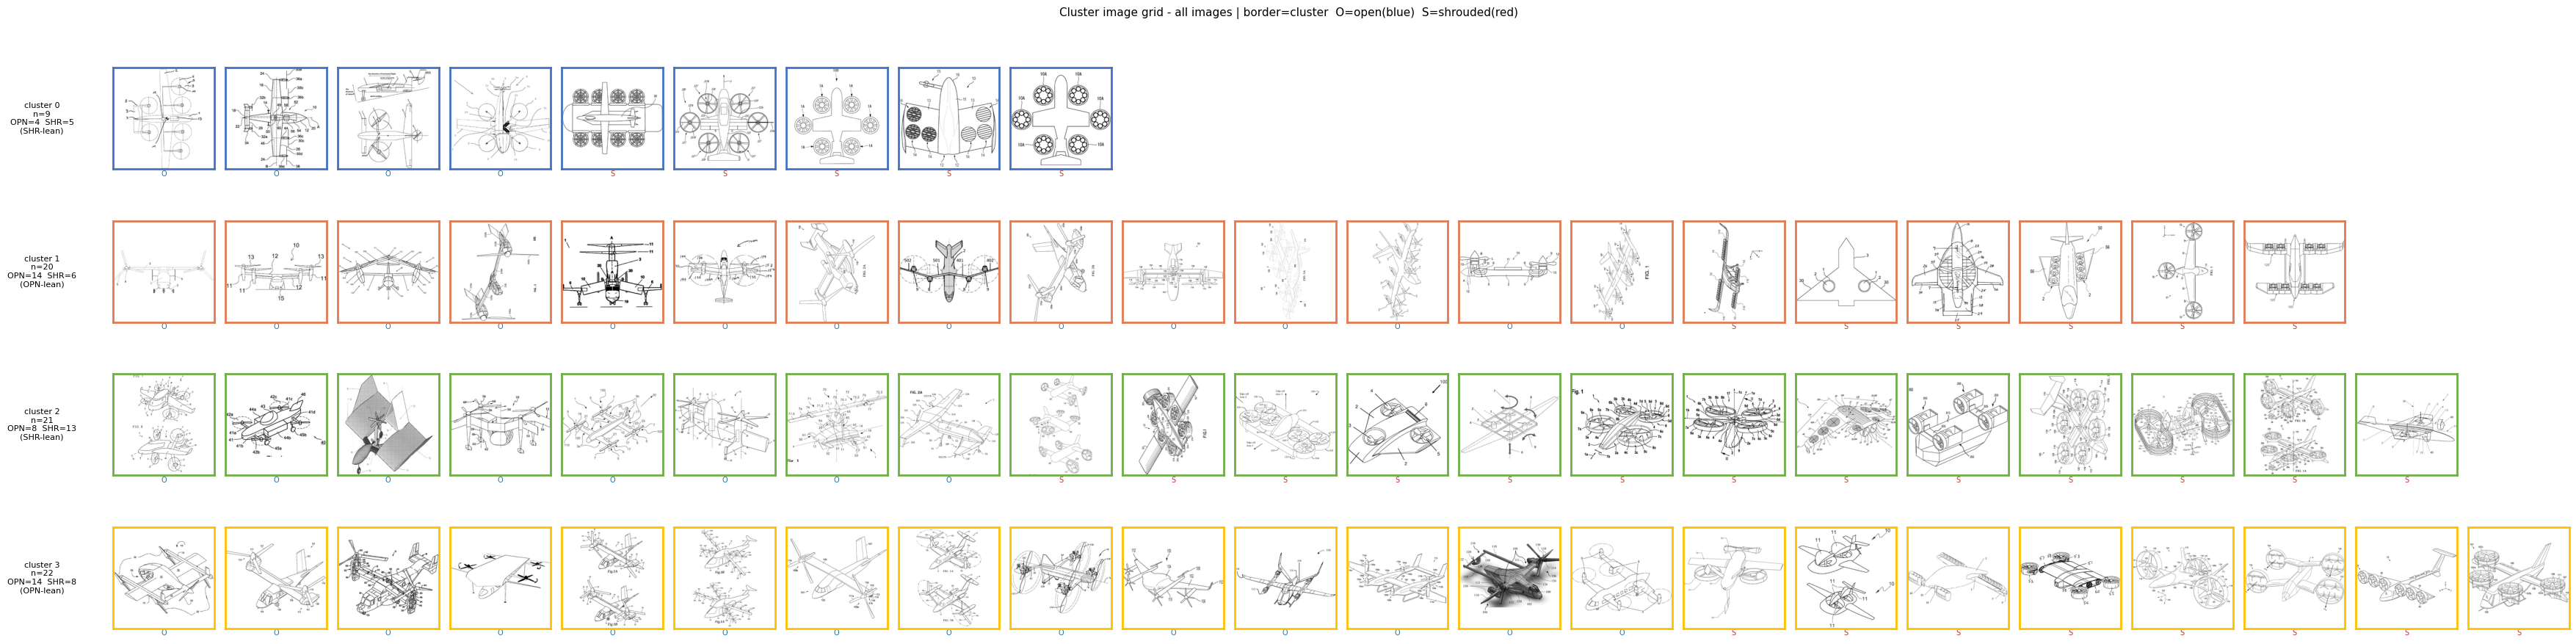

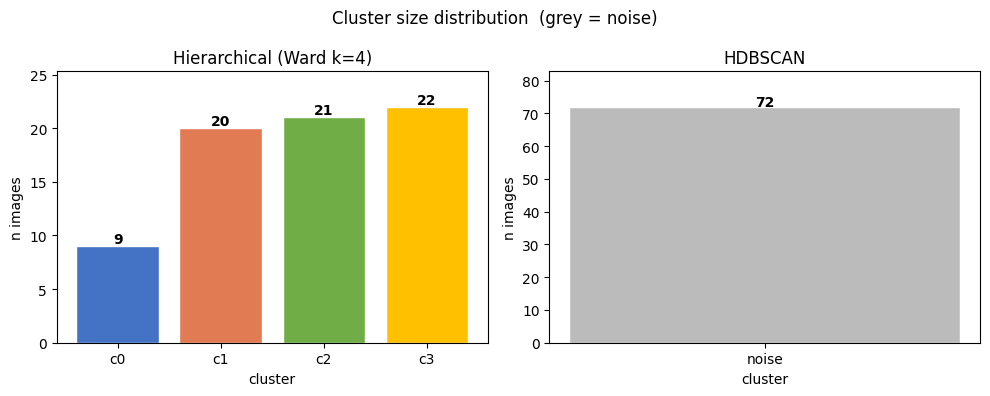

Hierarchical: {0: 9, 1: 20, 2: 21, 3: 22}
HDBSCAN: {'noise': 72}
  Silhouette > 0.10   : PASS  (0.207)
  Bootstrap ARI > 0.60: FAIL  (0.566 +/- 0.326)
  No fragmentation    : FAIL  (0 clusters)
  STAGE 2: FAIL


In [4]:
from sklearn.decomposition import PCA as _PCA
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score,
                             normalized_mutual_info_score)
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from src.analysis import _l2
import umap
from PIL import Image

CLUSTER_MATRIX = (22, 'mean_patch')
L_c, pool_c = CLUSTER_MATRIX
X_raw = _l2(arrays[CLUSTER_MATRIX])
n_pca = 39   # pcs_90 for layer 22 mean_patch; update from pca_stats.csv if needed
X_pca = _PCA(n_components=min(n_pca, X_raw.shape[0]-1), random_state=SEED).fit_transform(X_raw)
print(f'Input: layer {L_c} {pool_c}  PCA dim={X_pca.shape[1]}')

# ── 2a: Hierarchical clustering (Ward) + dendrogram ──────────────────────────
N_HIER   = 4
Z        = linkage(X_pca, method='ward')
leaf_lbl = [f"{r.patent_id[:12]}-{'S' if yb[i] else 'O'}"
            for i, r in metadata.reset_index(drop=True).iterrows()]
fig, ax  = plt.subplots(figsize=(18, 5))
dendrogram(Z, labels=leaf_lbl, leaf_rotation=90, leaf_font_size=6,
           color_threshold=0.7 * Z[-N_HIER, 2], ax=ax)
ax.set_title(f'Ward dendrogram — layer {L_c} {pool_c}  |  cut -> {N_HIER} clusters')
ax.set_ylabel('Ward distance'); fig.tight_layout()
fig.savefig(OUT[2] / 'dendrogram.png', dpi=130, bbox_inches='tight'); plt.show()
hier_labels   = fcluster(Z, t=N_HIER, criterion='maxclust') - 1
dominant_frac = pd.Series(hier_labels).value_counts().max() / len(hier_labels)
print(f'Hierarchical: {N_HIER} clusters  dominant fraction={dominant_frac:.2f}')


# ── 2a2: Dendrogram with patent images at leaves ─────────────────────────────
figures_paths = data.list_figures(cfg)[['figure_id','path','shrouded_open']].reset_index(drop=True)
meta_reset    = metadata.reset_index(drop=True)

n_leaves  = len(metadata)
CELL_W    = 1.3    # inches per leaf
FIG_W     = n_leaves * CELL_W
TREE_H    = 7.0
IMG_H     = 2.5

fig = plt.figure(figsize=(FIG_W, TREE_H + IMG_H))
gs  = fig.add_gridspec(2, 1, height_ratios=[TREE_H, IMG_H], hspace=0.05)

# ── top: dendrogram ──────────────────────────────────────────────────────────
ax_tree = fig.add_subplot(gs[0])
ddata = dendrogram(Z, ax=ax_tree, labels=list(range(n_leaves)),
                   leaf_rotation=0, leaf_font_size=0,
                   color_threshold=0.7 * Z[-N_HIER, 2])
ax_tree.set_xticks([])
ax_tree.set_ylabel('Ward distance', fontsize=11)
ax_tree.set_title(f'Ward dendrogram with patent images  |  layer {L_c} {pool_c}  '
                  f'|  {N_HIER} clusters  |  red border = shrouded  blue border = open',
                  fontsize=11, pad=10)

# scipy places leaves at x = 5, 15, 25, ...  (spacing 10), in tree-data coords
xs       = ddata['leaves']                       # leaf order = original indices
leaf_x   = np.arange(n_leaves) * 10.0 + 5.0      # data-x of each leaf

# Force a draw so axes positions/transforms are final, then map data-x -> fig fraction
fig.canvas.draw()
disp_pts = ax_tree.transData.transform(np.column_stack([leaf_x, np.zeros(n_leaves)]))
frac_x   = fig.transFigure.inverted().transform(disp_pts)[:, 0]

# bottom of tree panel / geometry for image strip (figure fraction)
tree_pos = ax_tree.get_position()
img_top  = tree_pos.y0 - 0.01
cell_w_f = (CELL_W / FIG_W) * 0.92                # slight gap between images
cell_h_f = img_top                                # images fill from 0 up to tree

for i, orig_idx in enumerate(xs):
    cx = frac_x[i]
    ax_img = fig.add_axes([cx - cell_w_f / 2, 0.0, cell_w_f, cell_h_f])
    ax_img.set_xticks([]); ax_img.set_yticks([])

    fid = meta_reset.loc[orig_idx, 'figure_id']
    row = figures_paths[figures_paths['figure_id'] == fid]
    if row.empty:
        ax_img.axis('off')
        continue
    so     = row.iloc[0]['shrouded_open']
    colour = '#c0392b' if so == 'SHR' else '#2471a3'
    try:
        img = Image.open(row.iloc[0]['path']).convert('RGB')
        ax_img.imshow(np.array(img), aspect='equal')
    except Exception:
        ax_img.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax_img.transAxes, fontsize=6)
    for spine in ax_img.spines.values():
        spine.set_edgecolor(colour); spine.set_linewidth(2.5)
    ax_img.set_xlabel('S' if so == 'SHR' else 'O', fontsize=7,
                      color=colour, labelpad=1, fontweight='bold')

fig.savefig(OUT[2] / 'dendrogram_images.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2b: HDBSCAN ──────────────────────────────────────────────────────────────
hdb        = HDBSCAN(min_cluster_size=6, min_samples=3, metric='euclidean').fit(X_pca)
hdb_labels = hdb.labels_
n_clusters = int((hdb_labels >= 0).any() and hdb_labels.max() + 1)
n_noise    = int((hdb_labels == -1).sum())
dom_hdb    = (pd.Series(hdb_labels[hdb_labels >= 0]).value_counts().max() / len(hdb_labels)
              if n_clusters > 0 else 1.0)
print(f'HDBSCAN: {n_clusters} clusters  noise={n_noise} ({n_noise/len(hdb_labels):.0%})')
if n_clusters >= 2:
    print(f'  ARI={adjusted_rand_score(yb, hdb_labels):+.3f}  NMI={normalized_mutual_info_score(yb, hdb_labels):.3f}')

# ── 2c: k-means + quality metrics ────────────────────────────────────────────
metric_rows = []
for k in [2, 3, 4]:
    km_k    = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit(X_pca).labels_
    hier_k  = fcluster(Z, t=k, criterion='maxclust') - 1
    for method, lbl in [('kmeans', km_k), ('hierarchical', hier_k)]:
        if len(np.unique(lbl)) < 2: continue
        metric_rows.append({'method': method, 'k': k,
            'silhouette':        round(silhouette_score(X_pca, lbl), 3),
            'davies_bouldin':    round(davies_bouldin_score(X_pca, lbl), 3),
            'calinski_harabasz': round(calinski_harabasz_score(X_pca, lbl), 1)})
hdb_ok = hdb_labels[hdb_labels >= 0]; hdb_Xok = X_pca[hdb_labels >= 0]
if len(np.unique(hdb_ok)) >= 2:
    metric_rows.append({'method': 'hdbscan', 'k': int(hdb_labels.max()+1),
        'silhouette':        round(silhouette_score(hdb_Xok, hdb_ok), 3),
        'davies_bouldin':    round(davies_bouldin_score(hdb_Xok, hdb_ok), 3),
        'calinski_harabasz': round(calinski_harabasz_score(hdb_Xok, hdb_ok), 1)})
metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(OUT[2] / 'cluster_metrics.csv', index=False)
display(metrics_df)

# ── 2d: Bootstrap cluster stability ──────────────────────────────────────────
best_k   = int(metrics_df[metrics_df['method']=='kmeans'].sort_values('silhouette').iloc[-1]['k'])
km_ref   = KMeans(n_clusters=best_k, n_init=20, random_state=SEED).fit(X_pca)
rng_b    = np.random.default_rng(SEED)
ari_boot = [adjusted_rand_score(km_ref.labels_,
            KMeans(n_clusters=best_k, n_init=10, random_state=int(rng_b.integers(1e6)))
            .fit(X_pca[rng_b.choice(len(X_pca), len(X_pca), replace=True)]).predict(X_pca))
            for _ in range(200)]
ari_mean, ari_std = np.mean(ari_boot), np.std(ari_boot)
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(ari_boot, bins=30, color='#4472c4', alpha=0.8)
ax.axvline(ari_mean, color='crimson', lw=2, label=f'mean ARI={ari_mean:.3f}')
ax.set_title(f'Cluster stability  k-means k={best_k}  (200 bootstrap runs)')
ax.set_xlabel('ARI'); ax.legend(); fig.tight_layout()
fig.savefig(OUT[2] / 'cluster_stability.png', dpi=130, bbox_inches='tight'); plt.show()

# ── 2e: UMAP coloured by clusters ────────────────────────────────────────────
emb_c  = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                   metric='cosine', random_state=SEED).fit_transform(X_raw)
pal    = ['#4472c4','#e07b54','#70ad47','#ffc000','#7030a0']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (lbl, title, meth) in zip(axes, [
        (hdb_labels, 'HDBSCAN', 'HDBSCAN'),
        (hier_labels, f'Ward k={N_HIER}', 'Hierarchical')]):
    colors = ['#bbbbbb' if l == -1 else pal[l % len(pal)] for l in lbl]
    ax.scatter(emb_c[:,0], emb_c[:,1], c=colors, s=55, alpha=0.85, edgecolors='white', lw=0.4)
    for l in sorted(set(lbl)):
        ax.scatter([],[], c='#bbbbbb' if l==-1 else pal[l%len(pal)],
                   label='noise' if l==-1 else f'c{l}', s=40)
    ax.legend(fontsize=8, title=meth); ax.set_title(f'UMAP — {title}')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Stage 2 clustering  layer {L_c} {pool_c}')
fig.tight_layout(); fig.savefig(OUT[2] / 'umap_clusters.png', dpi=150, bbox_inches='tight'); plt.show()

figures    = data.list_figures(cfg)[['figure_id', 'path']]
cluster_df = metadata[['figure_id','patent_id']].copy().reset_index(drop=True)
cluster_df = cluster_df.merge(figures, on='figure_id', how='left')
cluster_df['shrouded_open']   = np.where(yb==1, 'SHR', 'OPN')
cluster_df['hier_cluster']    = hier_labels
cluster_df['hdbscan_cluster'] = hdb_labels
cluster_df.to_csv(OUT[2] / 'cluster_labels.csv', index=False)

# ── 2f: Image grid — ALL images, one row per hierarchical cluster ─────────────
cluster_ids = sorted(cluster_df['hier_cluster'].unique())
max_per_row = int(cluster_df['hier_cluster'].value_counts().max())
n_rows = len(cluster_ids)

fig, axes = plt.subplots(n_rows, max_per_row,
                         figsize=(max_per_row * 1.6, n_rows * 2.2))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row, cid in enumerate(cluster_ids):
    subset  = cluster_df[cluster_df['hier_cluster'] == cid].reset_index(drop=True)
    n_opn   = int((subset['shrouded_open'] == 'OPN').sum())
    n_shr   = int((subset['shrouded_open'] == 'SHR').sum())
    n_total = len(subset)
    mix     = 'pure OPN' if n_shr == 0 else 'pure SHR' if n_opn == 0 else               'OPN-lean' if n_opn > n_shr else 'SHR-lean' if n_shr > n_opn else 'mixed'
    border  = pal[cid % len(pal)]

    for col in range(max_per_row):
        ax = axes[row, col]
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(border); spine.set_linewidth(2)
        if col < len(subset):
            try:
                img = Image.open(subset.loc[col, 'path']).convert('RGB')
                ax.imshow(img)
                lbl = 'S' if subset.loc[col, 'shrouded_open'] == 'SHR' else 'O'
                ax.set_xlabel(lbl, fontsize=7, labelpad=1,
                              color='#c0392b' if lbl == 'S' else '#2471a3')
            except Exception:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        transform=ax.transAxes, fontsize=7)
        else:
            ax.axis('off')

    axes[row, 0].set_ylabel(
        f'cluster {cid}\n'
        f'n={n_total}\n'
        f'OPN={n_opn}  SHR={n_shr}\n'
        f'({mix})',
        fontsize=8, rotation=0, labelpad=70, va='center')

fig.suptitle('Cluster image grid - all images | border=cluster  O=open(blue)  S=shrouded(red)',
             fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig(OUT[2] / 'cluster_image_grid.png', dpi=130, bbox_inches='tight')
plt.show()


# ── 2g: Cluster size distribution ────────────────────────────────────────────
_hier_counts = pd.Series(hier_labels).value_counts().sort_index()
_hdb_counts  = pd.Series(hdb_labels).value_counts().sort_index()
_hdb_counts.index = [f'noise' if i == -1 else f'c{i}' for i in _hdb_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar([f'c{i}' for i in _hier_counts.index], _hier_counts.values,
            color=[pal[i % len(pal)] for i in _hier_counts.index], edgecolor='white')
for i, v in enumerate(_hier_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title(f'Hierarchical (Ward k={N_HIER})')
axes[0].set_xlabel('cluster'); axes[0].set_ylabel('n images')
axes[0].set_ylim(0, _hier_counts.max() * 1.15)

_hdb_colors = ['#bbbbbb' if 'noise' in lbl else pal[int(lbl[1:]) % len(pal)]
               for lbl in _hdb_counts.index]
axes[1].bar(_hdb_counts.index, _hdb_counts.values,
            color=_hdb_colors, edgecolor='white')
for i, v in enumerate(_hdb_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('HDBSCAN')
axes[1].set_xlabel('cluster'); axes[1].set_ylabel('n images')
axes[1].set_ylim(0, _hdb_counts.max() * 1.15)

fig.suptitle('Cluster size distribution  (grey = noise)', fontsize=12)
fig.tight_layout()
fig.savefig(OUT[2] / 'cluster_size_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print('Hierarchical:', _hier_counts.to_dict())
print('HDBSCAN:',      _hdb_counts.to_dict())

# ── Stage 2 verdict ───────────────────────────────────────────────────────────
best_sil    = float(metrics_df['silhouette'].max())
sil_pass    = best_sil > 0.10
stable_pass = ari_mean > 0.60
frag_pass   = n_clusters >= 2 and dom_hdb <= 0.90
print('=' * 50)
print(f'  Silhouette > 0.10   : {"PASS" if sil_pass    else "FAIL"}  ({best_sil:.3f})')
print(f'  Bootstrap ARI > 0.60: {"PASS" if stable_pass else "FAIL"}  ({ari_mean:.3f} +/- {ari_std:.3f})')
print(f'  No fragmentation    : {"PASS" if frag_pass   else "FAIL"}  ({n_clusters} clusters)')
print('  STAGE 2:', 'PASS' if all([sil_pass, stable_pass, frag_pass]) else 'FAIL')
print('=' * 50)


## Stage 3 — Are the clusters meaningful?
**Question:** are the Stage-2 clusters internally good **and** do they line up with the known **shrouded/open** architecture — or do they reflect style / applicant / year confounds?
**Input:** all 6 embedding matrices + Stage-2 `cluster_labels.csv` / `cluster_metrics.csv` + Excel confounds.
**Outputs:** `structure_report.csv`, `permutation_separation.png`, `cluster_label_alignment.csv`, `cluster_enrichment.csv`, `cluster_quality_gates.csv`.

**Three things measured here:**
1. **Cluster quality** (§3e) — silhouette, Davies-Bouldin, bootstrap stability.
   *Pass:* silhouette clearly > 0 (>0.15), DBI not excessive (<2.0), stable (ARI>0.60).
   *Fail:* silhouette near 0 / negative, DBI very high, unstable.
2. **Cluster ↔ label alignment** (§3d) — Purity, NMI, ARI, per-cluster enrichment.
   *Pass:* ARI & NMI > 0.10 and ≥1 cluster significantly enriched → clusters recover the architecture.
   *Fail:* ARI/NMI ≈ 0, no enriched cluster → clusters are confounds, not rotor type.
3. **Supervised separability** (§3a–3c) — sep_ratio, probe AUC, permutation test.
   *Pass:* sep_ratio > 1, p < 0.05, AUC > 0.65 → a SHR/OPN direction exists even if clustering misses it.

> Frozen-backbone expectation: §3e and §3d both FAIL (no real clusters, no alignment) while §3a may pass weakly — the concept is faintly decodable but not the dominant axis of variation, motivating fine-tuning.

,layer,pooling,partic_dim,pcs_90,hopkins,sep_ratio,p_sep,silhouette,probe_auc,probe_acc,p_probe
0,18,cls,13.2,31,0.64,1.023,0.0790,0.023,0.689,0.695,0.0066
1,18,mean_patch,15.2,35,0.65,1.066,0.0010,0.049,0.708,0.584,0.1495
2,22,cls,21.0,44,0.67,1.087,0.0005,0.069,0.787,0.683,0.0100
3,22,mean_patch,18.5,39,0.59,1.076,0.0005,0.060,0.840,0.779,0.0033
4,24,cls,26.2,48,0.65,1.114,0.0005,0.095,0.836,0.765,0.0033
5,24,mean_patch,18.0,38,0.58,1.122,0.0005,0.097,0.839,0.750,0.0066


/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



--- Confound presence (is confound skewed by shrouded/open?) ---


,confound,test,stat_pos,stat_neg,p_value,verdict
0,filing_year,t-test,2017.10,2017.40,0.846,balanced
1,is_bell,chi2,0.42,0.45,1.000,balanced



--- Confound decodability (can embedding read the confound?) ---


,layer,pooling,design_auc,design_p,bell_auc,bell_p,year_r2,year_p
0,22,cls,0.787,0.0100,0.845,0.0033,-0.838,0.1362
1,24,mean_patch,0.839,0.0066,0.729,0.0365,-1.835,0.6512


layer22 cls: z=6.8  p=0.0001  effect=0.205
layer24 mean_patch: z=10.6  p=0.0001  effect=0.342


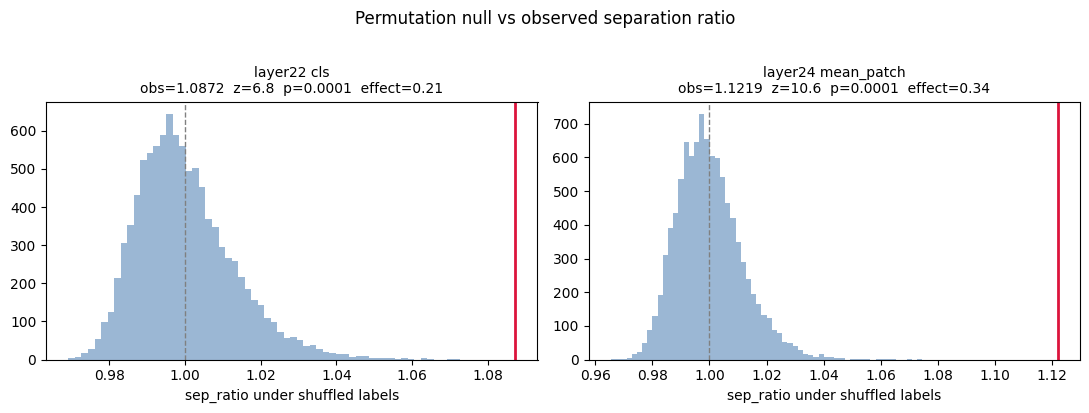

  sep_ratio > 1 & p < 0.05: PASS
  best probe AUC > 0.65   : PASS  (0.840 @ layer22 mean_patch)
  STAGE 3: PASS


,metric,value,baseline,good_min,status
0,Purity,0.639,0.556,0.706,FAIL
1,NMI,0.037,0.000,0.100,FAIL
2,ARI,0.022,0.000,0.100,FAIL


,cluster,n,OPN,SHR,pct_SHR,baseline_pct_SHR,lean,p_enrich,p_threshold,significant
0,0,9,4,5,56%,44%,SHR,0.498,0.05,no
1,1,20,14,6,30%,44%,OPN,0.186,0.05,no
2,2,21,8,13,62%,44%,SHR,0.071,0.05,no
3,3,22,14,8,36%,44%,OPN,0.444,0.05,no


  Purity 0.639 (baseline 0.556)  NMI 0.037  ARI 0.022
  significant clusters: 0/4
  CLUSTER MEANINGFULNESS: FAIL
  -> clusters DO NOT align with SHR/OPN -> reflect style/applicant/year confounds


,metric,value,good,status
0,silhouette,0.084,> 0.15,FAIL
1,davies_bouldin,2.411,< 2.0,FAIL
2,stability_ARI,0.482,> 0.6,FAIL


  silhouette     0.084  (good > 0.15)   FAIL — near 0, no real structure
  davies_bouldin 2.411  (good < 2.0)   FAIL — excessive
  stability ARI  0.482  (good > 0.6)   FAIL — unstable
  CLUSTER QUALITY: FAIL


In [5]:
# ── 3a: Structure report (sep_ratio, probe AUC, silhouette per matrix) ────────
report = analysis.structure_report(arrays, yb, n_perm_sep=2000, seed=SEED)
report.to_csv(OUT[3] / 'structure_report.csv', index=False)
display(report)

# ── 3b: Confound checks ───────────────────────────────────────────────────────
labels    = data.load_labels(cfg)
confounds = analysis.derive_confounds(metadata, labels)
print('\n--- Confound presence (is confound skewed by shrouded/open?) ---')
display(analysis.confound_presence(yb, confounds))
print('\n--- Confound decodability (can embedding read the confound?) ---')
display(analysis.confound_decodability(arrays, yb, confounds,
        matrices=[(22,'cls'),(24,'mean_patch')], seed=SEED))

# ── 3c: Permutation separation test (backbone significance claim) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (L, pool) in zip(axes, [(22,'cls'), (24,'mean_patch')]):
    r = analysis.permutation_separation(arrays[(L, pool)], yb, n_perm=10000, seed=SEED)
    ax.hist(r['null'], bins=60, color='#9bb7d4')
    ax.axvline(r['observed'], color='crimson', lw=2)
    ax.axvline(r['null_mean'], color='gray', ls='--', lw=1)
    ax.set_title(f'layer{L} {pool}\nobs={r["observed"]:.4f}  z={r["z_score"]:.1f}  '
                 f'p={r["p_value"]:.4f}  effect={r["effect_size"]:.2f}', fontsize=10)
    ax.set_xlabel('sep_ratio under shuffled labels')
    print(f'layer{L} {pool}: z={r["z_score"]:.1f}  p={r["p_value"]:.4f}  effect={r["effect_size"]:.3f}')
fig.suptitle('Permutation null vs observed separation ratio', y=1.02)
fig.tight_layout(); fig.savefig(OUT[3] / 'permutation_separation.png', dpi=130, bbox_inches='tight'); plt.show()

best = report.loc[report['probe_auc'].idxmax()]
sep_pass   = bool((report['sep_ratio'] > 1).any() and (report['p_sep'] < 0.05).any())
probe_pass = float(best['probe_auc']) > 0.65
print('=' * 50)
print(f'  sep_ratio > 1 & p < 0.05: {"PASS" if sep_pass   else "FAIL"}')
print(f'  best probe AUC > 0.65   : {"PASS" if probe_pass else "FAIL"}  ({best["probe_auc"]:.3f} @ layer{int(best["layer"])} {best["pooling"]})')
print('  STAGE 3:', 'PASS' if sep_pass and probe_pass else 'FAIL')
print('=' * 50)


# ── 3d: Cluster ↔ label alignment (Purity, NMI, ARI, enrichment) ─────────────
# Does the UNSUPERVISED Stage-2 clustering recover the SHR/OPN architecture?
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from scipy.stats import fisher_exact

_clu_csv = OUT[2] / 'cluster_labels.csv'
clu_df   = pd.read_csv(_clu_csv)
_mtag    = f'clustered on layer {L_c} {pool_c}  |  PCA-{X_pca.shape[1]}  |  Ward k={N_HIER}'
clu      = clu_df['hier_cluster'].values
lab      = (clu_df['shrouded_open'] == 'SHR').astype(int).values

def _purity(clusters, labels):
    return sum(np.max(np.bincount(labels[clusters == c]))
               for c in np.unique(clusters)) / len(labels)

base_purity = max(np.bincount(lab)) / len(lab)        # majority-class baseline
pur = _purity(clu, lab)
nmi = normalized_mutual_info_score(lab, clu)
ari = adjusted_rand_score(lab, clu)

# good_min = minimum value to count as meaningful (PASS threshold)
align = pd.DataFrame([
    {'metric': 'Purity', 'value': pur, 'baseline': base_purity, 'good_min': base_purity + 0.15},
    {'metric': 'NMI',    'value': nmi, 'baseline': 0.0,          'good_min': 0.10},
    {'metric': 'ARI',    'value': ari, 'baseline': 0.0,          'good_min': 0.10},
])
align['status'] = np.where(align['value'] >= align['good_min'], 'PASS', 'FAIL')
align.to_csv(OUT[3] / 'cluster_label_alignment.csv', index=False)

def _hl_status(s):
    return ['background-color:#c6efce' if v=='PASS' else 'background-color:#ffc7ce' for v in s]
display(align.style.format({'value': '{:.3f}', 'baseline': '{:.3f}', 'good_min': '{:.3f}'})
        .apply(_hl_status, subset=['status'])
        .set_caption(f'Clusters vs SHR/OPN — do clusters recover the architecture?  '
                     f'(good_min = PASS threshold  |  {_mtag})'))

# Per-cluster enrichment
n_shr_tot = int(lab.sum()); n_opn_tot = len(lab) - n_shr_tot
global_pct_shr = 100 * n_shr_tot / len(lab)   # baseline % SHR across all figures
P_SIG = 0.05                                  # significance threshold
rows = []
for c in np.unique(clu):
    m = clu == c; n = int(m.sum())
    n_shr = int(lab[m].sum()); n_opn = n - n_shr
    _, p = fisher_exact([[n_shr, n_opn], [n_shr_tot-n_shr, n_opn_tot-n_opn]])
    rows.append({'cluster': int(c), 'n': n, 'OPN': n_opn, 'SHR': n_shr,
                 'pct_SHR': 100*n_shr/n, 'baseline_pct_SHR': global_pct_shr,
                 'lean': 'SHR' if n_shr>n_opn else 'OPN' if n_opn>n_shr else 'even',
                 'p_enrich': p, 'p_threshold': P_SIG,
                 'significant': 'YES' if p < P_SIG else 'no'})
enr = pd.DataFrame(rows)
enr.to_csv(OUT[3] / 'cluster_enrichment.csv', index=False)

def _hl_sig(s):
    return ['background-color:#c6efce' if v=='YES' else 'background-color:#ffc7ce' for v in s]
display(enr.style.format({'pct_SHR': '{:.0f}%', 'baseline_pct_SHR': '{:.0f}%',
                          'p_enrich': '{:.3f}', 'p_threshold': '{:.2f}'})
        .apply(_hl_sig, subset=['significant'])
        .set_caption(f'Per-cluster SHR/OPN enrichment (Fisher exact vs rest)  '
                     f'(significant if p < {P_SIG}  |  baseline {global_pct_shr:.0f}% SHR  |  {_mtag})'))

# Verdict for the "are clusters meaningful?" question
align_pass = bool(ari > 0.10 and nmi > 0.10 and (enr['p_enrich'] < 0.05).any())
verdict = ('clusters ALIGN with architecture (useful structure)' if align_pass
           else 'clusters DO NOT align with SHR/OPN -> reflect style/applicant/year confounds')
print('=' * 60)
print(f'  Purity {pur:.3f} (baseline {base_purity:.3f})  NMI {nmi:.3f}  ARI {ari:.3f}')
print(f'  significant clusters: {int((enr["p_enrich"]<0.05).sum())}/{len(enr)}')
print(f'  CLUSTER MEANINGFULNESS: {"PASS" if align_pass else "FAIL"}')
print(f'  -> {verdict}')
print('=' * 60)


# ── 3e: Cluster-quality gates (silhouette, Davies-Bouldin, stability) ─────────
# Spec: silhouette clearly above 0, Davies-Bouldin not excessive, stable across runs.
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage as _linkage, fcluster as _fcluster

# Pull silhouette / DBI for the actual clustering (hierarchical, k=N_HIER) from Stage 2
_met = pd.read_csv(OUT[2] / 'cluster_metrics.csv')
_row = _met[(_met['method'] == 'hierarchical') & (_met['k'] == N_HIER)]
if _row.empty:                                  # fallback: recompute on the spot
    sil = silhouette_score(X_pca, hier_labels)
    dbi = davies_bouldin_score(X_pca, hier_labels)
else:
    sil = float(_row['silhouette'].iloc[0])
    dbi = float(_row['davies_bouldin'].iloc[0])

# Stability: bootstrap-resample, re-cluster, ARI vs reference labels
rng = np.random.default_rng(SEED)
ref = hier_labels
aris = []
for _ in range(200):
    idx = rng.choice(len(X_pca), len(X_pca), replace=True)
    lab_b = _fcluster(_linkage(X_pca[idx], method='ward'), t=N_HIER, criterion='maxclust') - 1
    aris.append(adjusted_rand_score(ref[idx], lab_b))
stab = float(np.mean(aris))

# Thresholds (good_min / good_max) per the spec
SIL_MIN, DBI_MAX, STAB_MIN = 0.15, 2.0, 0.60
qual = pd.DataFrame([
    {'metric': 'silhouette',     'value': sil,  'good':  f'> {SIL_MIN}',  'status': 'PASS' if sil  > SIL_MIN  else 'FAIL'},
    {'metric': 'davies_bouldin', 'value': dbi,  'good':  f'< {DBI_MAX}',  'status': 'PASS' if dbi  < DBI_MAX  else 'FAIL'},
    {'metric': 'stability_ARI',  'value': stab, 'good':  f'> {STAB_MIN}', 'status': 'PASS' if stab > STAB_MIN else 'FAIL'},
])
qual.to_csv(OUT[3] / 'cluster_quality_gates.csv', index=False)

def _hl_q(s):
    return ['background-color:#c6efce' if v=='PASS' else 'background-color:#ffc7ce' for v in s]
display(qual.style.format({'value': '{:.3f}'}).apply(_hl_q, subset=['status'])
        .set_caption(f'Cluster-quality gates  (silhouette>0 clearly, DBI not excessive, stable)  ({_mtag})'))

quality_pass = bool(sil > SIL_MIN and dbi < DBI_MAX and stab > STAB_MIN)
print('=' * 60)
print(f'  silhouette     {sil:.3f}  (good > {SIL_MIN})   {"PASS" if sil>SIL_MIN else "FAIL — near 0, no real structure"}')
print(f'  davies_bouldin {dbi:.3f}  (good < {DBI_MAX})   {"PASS" if dbi<DBI_MAX else "FAIL — excessive"}')
print(f'  stability ARI  {stab:.3f}  (good > {STAB_MIN})   {"PASS" if stab>STAB_MIN else "FAIL — unstable"}')
print(f'  CLUSTER QUALITY: {"PASS" if quality_pass else "FAIL"}')
print('=' * 60)

## Stage 4 — Are same-patent images close to each other?
**Question:** do multiple figures of the *same* patent embed close together (view-consistent), or is the backbone too view-sensitive?
**Input:** intra-patent vs inter-patent distances → ratio.
**Status:** ⚠️ **NOT APPLICABLE to this dataset** — the Shrouded-vs-Open subset keeps exactly **1 figure per patent** (72 figures / 72 patents), so there are **zero intra-patent pairs** and the ratio is undefined.
**To run later:** needs a multi-figure-per-patent extraction (several views/drawings per patent).

In [6]:
# ── Stage 4: view-consistency — not computable on this dataset ────────────────
fpp = data.list_figures(cfg)['patent_id'].value_counts()
print(f'figures/patent: min={fpp.min()}  median={fpp.median():.0f}  max={fpp.max()}')
print(f'patents with >1 figure: {int((fpp > 1).sum())} / {fpp.size}')
print('=' * 60)
if (fpp > 1).sum() == 0:
    print('STAGE 4: N/A — exactly 1 figure per patent, no intra-patent pairs.')
    print('Intra-patent distance is undefined; document as not-applicable.')
else:
    print('multi-figure patents exist -> implement intra/inter-patent ratio here.')
print('=' * 60)

Stage 4: TODO


## Stage 5 — Which information is encoded?
**Question:** what can a *lightweight* probe read off the frozen embeddings? We want the **design concepts** we care about to be decodable and the **nuisance / "invisible" labels** to stay near chance.
**Input:** frozen embeddings + labels (architecture SHR/OPN, CPC class) + confounds (filing year, assignee).
**Probes:** k-NN (cosine) and logistic / ridge regression on PCA-50, 5-fold CV.
**Metrics:** k-NN accuracy, linear-probe accuracy/AUC, macro-F1, Spearman (for year).
**Outputs:** `probe_scores.csv`, `probe_decodability.png`.

| target | category | want |
|---|---|---|
| architecture (SHR/OPN) | design concept | **above chance** |
| CPC technical class | design concept | **above chance** |
| filing year | invisible / nuisance | near chance (R²≈0, ρ≈0) |
| assignee = Bell/Textron | invisible / nuisance | near chance (AUC≈0.5) |

**Pass:** design concepts recovered above chance **and** invisible labels near chance.
**Fail:** everything near chance (nothing encoded) — or invisible labels decodable (leakage/confound).

In [7]:
# ── 5a: probe helpers (k-NN + continuous) ────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold, KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA as _PCA5
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from src.analysis import _l2, linear_probe, multiclass_probe

def knn_probe(X, y, k=5, n_pca=50, seed=SEED):
    """k-NN (cosine) CV accuracy + macro-F1 on PCA-reduced embeddings."""
    y = np.asarray(y)
    Xp = _PCA5(n_components=min(n_pca, X.shape[0]-1), random_state=seed).fit_transform(_l2(X))
    n_splits = int(min(5, pd.Series(y).value_counts().min()))
    cv  = StratifiedKFold(n_splits, shuffle=True, random_state=seed)
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    acc = float(cross_val_score(knn, Xp, y, cv=cv, scoring='accuracy').mean())
    f1  = float(cross_val_score(knn, Xp, y, cv=cv, scoring='f1_macro').mean())
    return acc, f1

def cont_probe(X, yv, n_pca=50, seed=SEED):
    """Ridge probe for a continuous target -> R² + Spearman ρ of CV predictions."""
    yv = np.asarray(yv, dtype=float)
    m  = ~np.isnan(yv)
    Xp = _PCA5(n_components=min(n_pca, m.sum()-1), random_state=seed).fit_transform(_l2(X[m]))
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
    pred = cross_val_predict(pipe, Xp, yv[m], cv=KFold(5, shuffle=True, random_state=seed))
    return float(r2_score(yv[m], pred)), float(spearmanr(yv[m], pred).correlation)

# ── 5b: find the best layer for the DESIGN concept (architecture SHR/OPN) ─────
arch_rows = []
for key in sorted(arrays.keys()):
    L, pool = key
    lp = linear_probe(arrays[key], yb, n_pca=50, n_perm=200, seed=SEED)
    ka, kf = knn_probe(arrays[key], yb)
    arch_rows.append({'layer': L, 'pooling': pool, 'logreg_auc': lp['auc'],
                      'logreg_acc': lp['accuracy'], 'knn_acc': ka, 'knn_f1': kf,
                      'p_value': lp['p_value']})
arch_df = pd.DataFrame(arch_rows).sort_values('logreg_auc', ascending=False).reset_index(drop=True)
display(arch_df.style.format({'logreg_auc':'{:.3f}','logreg_acc':'{:.3f}',
        'knn_acc':'{:.3f}','knn_f1':'{:.3f}','p_value':'{:.3f}'})
        .set_caption('Architecture (SHR/OPN) decodability per layer — pick the best backbone'))
best_key = (int(arch_df.iloc[0]['layer']), arch_df.iloc[0]['pooling'])
Xbest = arrays[best_key]
print(f'best matrix for architecture: layer {best_key[0]} {best_key[1]}  (AUC {arch_df.iloc[0]["logreg_auc"]:.3f})')

# ── 5c: full probe battery on the best matrix ────────────────────────────────
labels    = data.load_labels(cfg)
confounds = analysis.derive_confounds(metadata, labels)
cpc       = metadata.merge(data.list_figures(cfg)[['figure_id','cpc']],
                           on='figure_id', how='left')['cpc'].values

chance_arch = float(max(np.bincount(yb)) / len(yb))     # majority-class accuracy

# architecture
lp_a            = linear_probe(Xbest, yb, n_pca=50, n_perm=300, seed=SEED)
knn_a_acc, knn_a_f1 = knn_probe(Xbest, yb)
# CPC class
mc              = multiclass_probe(Xbest, cpc, n_pca=50, n_perm=300, min_per_class=4, seed=SEED)
knn_c_acc, knn_c_f1 = knn_probe(Xbest, cpc)
# filing year (invisible/continuous)
r2_year, rho_year = cont_probe(Xbest, confounds['filing_year'].to_numpy(float))
# assignee = Bell/Textron (invisible/binary)
lp_b            = linear_probe(Xbest, confounds['is_bell'].to_numpy(), n_pca=50, n_perm=300, seed=SEED)
knn_b_acc, _    = knn_probe(Xbest, confounds['is_bell'].to_numpy())

probe_scores = pd.DataFrame([
    {'target':'architecture (SHR/OPN)','category':'design','knn_acc':knn_a_acc,'logreg_acc':lp_a['accuracy'],
     'auc':lp_a['auc'],'macro_f1':knn_a_f1,'spearman':np.nan,'chance':chance_arch,'p':lp_a['p_value']},
    {'target':'CPC technical class','category':'design','knn_acc':knn_c_acc,'logreg_acc':mc['balanced_acc'],
     'auc':mc['macro_auc'],'macro_f1':mc['macro_f1'],'spearman':np.nan,'chance':mc['chance'],'p':mc['p_value']},
    {'target':'filing year','category':'invisible','knn_acc':np.nan,'logreg_acc':np.nan,
     'auc':np.nan,'macro_f1':np.nan,'spearman':rho_year,'chance':0.0,'p':np.nan},
    {'target':'assignee = Bell/Textron','category':'invisible','knn_acc':knn_b_acc,'logreg_acc':lp_b['accuracy'],
     'auc':lp_b['auc'],'macro_f1':np.nan,'spearman':np.nan,'chance':0.5,'p':lp_b['p_value']},
])
probe_scores.to_csv(OUT[5] / 'probe_scores.csv', index=False)

def _hl_cat(row):
    c = '#eaf4ff' if row['category']=='design' else '#fff3e6'
    return [f'background-color:{c}'] * len(row)
display(probe_scores.style.format({'knn_acc':'{:.3f}','logreg_acc':'{:.3f}','auc':'{:.3f}',
        'macro_f1':'{:.3f}','spearman':'{:.3f}','chance':'{:.3f}','p':'{:.3f}'}, na_rep='—')
        .apply(_hl_cat, axis=1)
        .set_caption(f'Probe battery on layer {best_key[0]} {best_key[1]}  '
                     f'(blue = design concept, want high  |  orange = invisible, want ~chance)'))

# ── 5d: decodability bar (signal above chance, normalised) ────────────────────
def _signal(row):
    if row['target']=='filing year':                 return abs(row['spearman'])      # ρ, chance 0
    if not np.isnan(row['auc']):                      return max(0.0,(row['auc']-0.5)/0.5)  # AUC->[0,1]
    return max(0.0,(row['logreg_acc']-row['chance'])/(1-row['chance']))
probe_scores['signal'] = probe_scores.apply(_signal, axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
colours = ['#2471a3' if c=='design' else '#e67e22' for c in probe_scores['category']]
ax.barh(probe_scores['target'], probe_scores['signal'], color=colours)
ax.axvline(0, color='gray', lw=1)
ax.axvline(0.2, color='crimson', ls='--', lw=1, label='weak-signal threshold (0.2)')
ax.set_xlabel('normalised decodability above chance  (0 = chance, 1 = perfect)')
ax.set_title(f'What the frozen backbone encodes — layer {best_key[0]} {best_key[1]}')
ax.legend(fontsize=8); ax.invert_yaxis()
fig.tight_layout(); fig.savefig(OUT[5] / 'probe_decodability.png', dpi=130, bbox_inches='tight'); plt.show()

# ── verdict ───────────────────────────────────────────────────────────────────
design_ok   = bool((probe_scores.loc[probe_scores.category=='design','signal'] > 0.2).any())
invisible_ok = bool((probe_scores.loc[probe_scores.category=='invisible','signal'] < 0.2).all())
print('=' * 62)
print(f'  design concepts decodable (>0.2 signal) : {"PASS" if design_ok else "FAIL"}')
print(f'  invisible labels near chance (<0.2)      : {"PASS" if invisible_ok else "FAIL — possible leakage"}')
print(f'  STAGE 5: {"PASS" if design_ok and invisible_ok else "FAIL"}')
print('=' * 62)

Stage 5: N/A — 1 figure per patent. Intra-patent distance undefined.


## Stage 6 — What Is Encoded
**Question:** is the shrouded/open distinction linearly decodable from the embedding?  
**Input:** best embedding matrix, labels  
**Outputs:** `probe_report.csv, knn_probe.csv`  
**Pass:** logistic AUC > 0.7 and k-NN accuracy > 0.65  
**Fail:** probes at chance — label not encoded


In [8]:
# Stage 6 — not yet implemented
print("Stage 6: TODO")


Stage 6: TODO


## Stage 7 — Confound Testing
**Question:** is the design signal explained by jurisdiction, figure type, or other metadata?  
**Input:** embedding matrices, metadata  
**Outputs:** `confound_report.csv`  
**Pass:** all confounds either balanced or not decodable  
**Fail:** a decodable AND skewed confound explains the design signal


In [9]:
# Stage 7 — not yet implemented
print("Stage 7: TODO")


Stage 7: TODO


## Stage 8 — Layer Comparison
**Question:** which layer and pooling strategy gives the strongest signal?  
**Input:** all 6 embedding matrices  
**Outputs:** `layer_comparison.csv, layer_comparison.png`  
**Pass:** clear winner identified with consistent ranking across metrics  
**Fail:** no consistent winner — signal is layer-agnostic noise


In [10]:
# Stage 8 — not yet implemented
print("Stage 8: TODO")


Stage 8: TODO


## Stage 9 — Temporal / Genealogical Signal
**Question:** does filing year or patent citation graph correlate with embedding distance?  
**Input:** best embedding matrix, filing years  
**Outputs:** `temporal_signal.csv, centroid_drift.png`  
**Pass:** centroid drift detectable OR citation-NN precision > random  
**Fail:** no temporal or genealogical signal


In [11]:
# Stage 9 — not yet implemented
print("Stage 9: TODO")


Stage 9: TODO
